# #123 evidence notebook

Thin view over `experiments/analysis`; contains no results. Point `RUNS` at pulled run directories (see `docs/inference-experiments/inference-run-playbook.md`). Every output states its evidence scope: **per-request** (requests.jsonl) or **WINDOW-level** (Prometheus; never per request).

## What these experiments are testing

Two vLLM workers serve the same model and keep separate prefix caches. The experiment
sequence separates capacity, restart effects, cache reuse, routing and overload protection.
The descriptions below follow the **runbook/playbook definitions**; older testing-guide
sections use different names for E0 and E2.

| Experiment | Question | What changes | Main evidence |
|---|---|---|---|
| E0 — capacity | What saturates first as offered load increases? | Concurrency and synthetic context length | Throughput, goodput, latency, running/waiting and KV usage |
| E1 — restart / warmup | Is the first request after readiness slower than later requests? | Immediately after restart vs declared-warm state | First-request TTFT, subsequent-request percentiles; startup logs separately |
| E2 — prefix reuse | Does an already cached prompt prefix reduce latency? | First replay after reset vs identical replay without reset | TTFT by turn, manifest parity, window-level cache-hit deltas |
| E3 — routing | Does preferring the worker holding the prefix beat spreading load? | `least_loaded` vs `prefix_then_load` | TTFT by turn and worker, tail latency, placement and reuse evidence |
| E4 — admission | Does rejecting work early preserve useful interactive service under overload? | Capacity/deadline shedding off vs on | Interactive goodput, tail latency, sheds, fairness and starvation |
| E5 — locality / recompute control | What does recomputing on another worker cost? | Local reuse vs recompute vs independently warmed destination | Latency and cache evidence at several prefix sizes; real KV transfer needs #133 |

**Terms used in the charts.** TTFT means time to first generated content token; E2E means
elapsed time until the request completes. p50 is the median; p95 is a tail percentile
(about 95% of observations are at or below it). Offered concurrency is the replay's
in-flight workload limit, not a guaranteed count of simultaneously executing GPU requests.
Prefill processes the input prompt; decode generates output tokens. The KV cache stores
attention keys and values; prefix reuse avoids recomputing matching cached prompt tokens.
HBM is GPU memory. A latency SLO is the threshold defining a useful completion.

**How to read this report.** Descriptions are experimental intent, not findings. Supplied
runs produce charts and tables; optional session writeups explain measured results and
caveats. Missing runs are skipped, so a description alone does not prove an experiment ran.
Per-request replay latency includes the transport path; Prometheus samples and cache-hit
ratios describe a whole window. Check parity and repeat runs before making a causal or
statistical claim.

**Expected vs observed.** Each section states the hypothesis separately from the supplied
run's observations. Expected behavior is not an acceptance result. The E0–E3 session
writeups contain the observed findings and caveats; E4/E5 have no observations in this
session because those runs have not been supplied.

**Next validation:** we will rerun the experiments once more from scratch, with fresh
setup, recorded pre-flight checks and deliberate cache resets for each comparison.
The current observations are preliminary. The rerun should check whether the patterns
repeat; it must not assume the same numerical results. Keep both sessions' artifacts
and compare them rather than replacing the original evidence.

**Repository sources:** `docs/inference-experiments/inference-experiments-reference.md`
(definitions), `inference-run-playbook.md` and `inference-session-runbook.md` (procedure),
`inference-testing-guide.md` (methodology and policy semantics), `inference-evidence-index.md`
(proof requirements), and this folder's `README.md` (observability and scrape caveats).


In [1]:
import json, os, sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "experiments" / "analysis").is_dir())
sys.path.insert(0, str(ROOT))
from experiments.analysis import (breakdown, e2_prefix_reuse, e3_compare, e4_compare,
                                  load_run, memory_proof, queue_proof, sweep_curve, ttft_by_turn)
from experiments.analysis.display import show as plain_show, flatten
from html import escape
try:
    from IPython import get_ipython
    from IPython.display import HTML, Markdown, display
except ImportError:
    get_ipython = lambda: None
    HTML = Markdown = str
    display = print


def show(title, result):
    """Readable notebook tables; retain CLI output when no notebook kernel is active."""
    shell = get_ipython()
    if shell is None or not hasattr(shell, "kernel"):
        return plain_show(title, result)

    def value(v):
        if v is None:
            return "unavailable"
        if isinstance(v, float):
            return f"{v:,.2f}"
        return str(v)

    def table(rows):
        keys = list(dict.fromkeys(k for row in rows for k in row))
        head = "".join(f"<th>{escape(k)}</th>" for k in keys)
        body = "".join("<tr>" + "".join(f"<td>{escape(value(row.get(k)))}</td>" for k in keys) + "</tr>" for row in rows)
        return f"<div style='overflow-x:auto'><table><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table></div>"

    def render(obj):
        if isinstance(obj, dict):
            scalar = [{"metric": k, "value": v} for k, v in obj.items() if not isinstance(v, (dict, list))]
            out = table(scalar) if scalar else ""
            for key, v in obj.items():
                if isinstance(v, (dict, list)) and v:
                    out += f"<h4>{escape(key)}</h4>" + render(v)
            return out
        if isinstance(obj, list):
            if all(isinstance(v, dict) for v in obj):
                return table([flatten(v) for v in obj])
            return "<ul>" + "".join(f"<li>{escape(value(v))}</li>" for v in obj) + "</ul>"
        return f"<p>{escape(value(obj))}</p>"

    display(HTML(f"<h3>{escape(title)}</h3>" + render(result)))


def writeup(experiment):
    """Optionally include a session's Markdown talk track without committing local results."""
    directory = os.environ.get("EVIDENCE_WRITEUP_DIR")
    if directory:
        path = Path(directory) / f"{experiment.lower()}.md"
        if path.is_file():
            display(Markdown(f"## Observed results and interpretation — {experiment}"))
            display(Markdown(path.read_text(encoding="utf-8")))

# Fill in pulled run directories (metrics/inference/<run-id>/<scenario_strategy_ts>/), or set the
# env var EVIDENCE_RUNS_JSON to a JSON object with the same keys. None = not provided.
RUNS = {
    "E0_SWEEP": None,          # run dir from an offered-load sweep (sweep.csv/json)
    "E0_CAPACITY": None,       # dir containing capacity_summary.json (#120 capacity runner)
    "E1_WARMUP_COLD": None,    # dir containing warmup_summary.json right after a worker restart
    "E1_WARMUP_WARM": None,    # dir containing warmup_summary.json after declared warm-up
    "E2_COLD": None, "E2_REUSED": None,
    "E3_LEAST_LOADED": None, "E3_PREFIX_THEN_LOAD": None,
    "E4_ADMISSION_OFF": None, "E4_ADMISSION_ON": None,
    "E5_RUN": None,            # any gateway run dir (recompute control); shown by turn and worker
    "MEMORY_RANGE": None,      # metrics/inference/<run-id>/prometheus_range
    "QUEUE_RANGE": None,       # metrics/inference/<run-id>/prometheus_range (gateway queue vs vLLM waiting)
}
RUNS.update(json.loads(os.environ.get("EVIDENCE_RUNS_JSON", "{}")))


def need(*keys):
    """Return the Paths for keys, or print why the experiment cell is skipped."""
    missing = [k for k in keys if not RUNS.get(k)]
    if missing:
        print(f"run directory not provided: set RUNS{missing}; skipping this experiment")
        return None
    return [Path(RUNS[k]) for k in keys]




In [2]:
# Chart helpers: missing values stay missing; captions preserve evidence scope.
from experiments.analysis.runs import latency_stats

BLUE, ORANGE, AQUA, INK, MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#52514e"
COLORS = [BLUE, ORANGE, AQUA]
try:
    import matplotlib
    if get_ipython() is None:
        matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    plt.rcParams.update({
        "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "axes.grid.axis": "y",
        "axes.axisbelow": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.edgecolor": "#c9c8c2",
        "text.color": INK, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
        "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "figure.dpi": 110,
    })
except ImportError:
    plt = None
    print("matplotlib not installed: charts are skipped, tables only")


def plot_sweep(curve):
    if plt is None or not curve["rows"]:
        return
    rows = curve["rows"]
    x = [r["offered_concurrency"] for r in rows]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    for key, label in (("completed_rps", "completed throughput"), ("good_rps", "SLO-qualified goodput")):
        axes[0].plot(x, [r[key] for r in rows], marker="o", label=label)
    axes[0].set_ylabel("requests / second")
    axes[0].set_title("Completions vs useful completions", loc="left")
    for key, label in (("ttft_p95_ms", "TTFT p95"), ("e2e_p95_ms", "E2E p95")):
        axes[1].plot(x, [r[key] for r in rows], marker="o", label=label)
    axes[1].set_ylabel("client latency (ms)")
    axes[1].set_title("Latency cost of offered load", loc="left")
    for ax in axes:
        ax.set_xlabel("offered concurrency")
        ax.set_xticks(x)
        ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()


def worker_name(url):
    return {"18001": "worker A", "18002": "worker B"}.get(str(url).rstrip("/").rsplit(":", 1)[-1], str(url))


def bars(ax, groups, series, ylabel, title):
    n = len(series)
    w = 0.8 / n
    for i, (label, vals) in enumerate(series.items()):
        vals = [float("nan") if v is None else v for v in vals]
        xs = [g + (i - (n - 1) / 2) * w for g in range(len(groups))]
        rects = ax.bar(xs, vals, w * 0.92, label=label, color=COLORS[i % len(COLORS)])
        ax.bar_label(rects, labels=["n/a" if v != v else f"{v:,.0f}" for v in vals], fontsize=8, color=MUTED, padding=2)
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups)
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc="left", fontsize=10, color=INK)
    ax.legend(frameon=False, fontsize=8)


def turn_stat(run, stat):
    rows = ttft_by_turn(run)["rows"]
    turns = sorted(rows, key=lambda t: int(t.split("_")[1]))
    return [t.replace("turn_", "turn ") for t in turns], [rows[t]["ttft_ms"][stat] for t in turns]


def compare_by_turn(title, a_label, a_run, b_label, b_run):
    if plt is None:
        return
    ra, rb = ttft_by_turn(a_run)["rows"], ttft_by_turn(b_run)["rows"]
    keys = sorted(set(ra) | set(rb), key=lambda t: int(t.split("_")[1]))
    turns = [t.replace("turn_", "turn ") for t in keys]
    a50 = [(ra.get(t, {}).get("ttft_ms") or {}).get("p50") for t in keys]
    b50 = [(rb.get(t, {}).get("ttft_ms") or {}).get("p50") for t in keys]
    sa, sb = (latency_stats(r.select())["ttft_ms"] for r in (a_run, b_run))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [3, 1.6]})
    bars(ax1, turns, {a_label: a50, b_label: b50}, "client TTFT p50 (ms)", f"{title}: TTFT p50 by turn")
    bars(ax2, ["p50", "p95"], {a_label: [sa["p50"], sa["p95"]], b_label: [sb["p50"], sb["p95"]]},
         "client TTFT (ms)", "all turns")
    fig.text(0.01, -0.02, "Replay TTFT includes the client transport path. Missing observations are not zero.", fontsize=8, color=MUTED)
    plt.tight_layout()
    plt.show()


def compare_breakdown(title, by, a_label, a_run, b_label, b_run, stat="p95"):
    if plt is None:
        return
    ra, rb = breakdown(a_run, by)["rows"], breakdown(b_run, by)["rows"]
    groups = sorted(set(ra) | set(rb))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
    get = lambda rows, g, k: (rows.get(g, {}).get("ttft_ms") or {}).get(k) if k != "n" else rows.get(g, {}).get("requests", 0)
    bars(ax1, groups, {a_label: [get(ra, g, stat) for g in groups], b_label: [get(rb, g, stat) for g in groups]},
         f"client TTFT {stat} (ms)", f"{title}: TTFT {stat} by {by}")
    bars(ax2, groups, {a_label: [get(ra, g, "n") for g in groups], b_label: [get(rb, g, "n") for g in groups]},
         "requests", f"requests by {by}")
    plt.tight_layout()
    plt.show()


def plot_capacity(summary):
    if plt is None:
        return
    sweep = summary.get("live_sweep", [])
    if not sweep:
        return print("No live capacity sweep observations available")
    ctxs = sorted({x["context_length_target"] for x in sweep})
    cap = (summary.get("configured_ceiling") or {}).get("value")
    fig, axes = plt.subplots(1, len(ctxs), figsize=(11, 3.4), sharey=True, squeeze=False)
    axes = axes[0]
    for ax, c in zip(axes, ctxs):
        rows = [x for x in sweep if x["context_length_target"] == c]
        xs = [x["concurrency"] for x in rows]
        ax.plot(xs, [x["peak_running"] for x in rows], marker="o", color=BLUE, label="peak running")
        ax.plot(xs, [x["peak_waiting"] for x in rows], marker="o", color=ORANGE, label="peak waiting")
        if cap:
            ax.axhline(cap, color=MUTED, linestyle="--", linewidth=1)
        ax.set_xticks(xs)
        ax.set_title(f"{c}-token context", loc="left", fontsize=10, color=INK)
        ax.set_xlabel("offered concurrency")
    axes[0].set_ylabel("requests in engine (peak)")
    axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle(f"E0 capacity: observed running and waiting; configured ceiling={cap}", x=0.01, ha="left", fontsize=10)
    plt.tight_layout()
    plt.show()


def plot_memory(res):
    if plt is None:
        return
    ts, ser = res["timestamps"], res["series"]
    if not ts:
        return print("No memory range samples available")
    t = [(x - ts[0]) / 60 for x in ts]
    active = [i for i in range(len(ts)) if any((v[i] or 0) > 0 for k, v in ser.items() if "kv_cache" in k or "requests_" in k)]
    lo, hi = (max(min(active) - 8, 0), min(max(active) + 8, len(ts))) if active else (0, len(ts))
    t, ser = t[lo:hi], {k: v[lo:hi] for k, v in ser.items()}
    panels = [
        ("HBM used (GiB)", "dcgm_fb_used_mib", 1 / 1024),
        ("KV cache usage (%)", "vllm_kv_cache_usage", 100),
        ("requests running", "vllm_requests_running", 1),
        ("requests waiting", "vllm_requests_waiting", 1),
    ]
    fig, axes = plt.subplots(len(panels), 1, figsize=(11, 7.5), sharex=True)
    for ax, (label, prefix, k) in zip(axes, panels):
        lines = [(name, vals) for name, vals in ser.items() if name.split(":")[0] == prefix]
        for i, (name, vals) in enumerate(lines):
            if vals is not None:
                ax.plot(t, [None if v is None else v * k for v in vals], color=COLORS[i % len(COLORS)], label=name, linewidth=1.6)
        ax.set_ylabel(label)
        if lines:
            ax.legend(frameon=False, fontsize=8, loc="upper left")
    axes[0].set_title("Memory proof (WINDOW-level samples): HBM, KV, running and waiting, zoomed to the active part of the supplied window", loc="left", fontsize=10, color=INK)
    axes[-1].set_xlabel("minutes since window start (idle lead-in and tail trimmed)")
    plt.tight_layout()
    plt.show()


def plot_queue(res):
    if plt is None:
        return
    ts, ser = res["timestamps"], res["series"]
    if not ts:
        return print("No queue range samples available")
    t = [(x - ts[0]) / 60 for x in ts]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
    q_lines = [(name, vals) for name, vals in ser.items() if "orch_replica_queue_depth" in name]
    w_lines = [(name, vals) for name, vals in ser.items() if "vllm_requests_waiting" in name]
    for i, (name, vals) in enumerate(q_lines):
        if vals is not None:
            ax1.plot(t, vals, color=COLORS[i % len(COLORS)], label=f"gateway queue: {name.split(':', 1)[-1]}", linewidth=1.6)
    for i, (name, vals) in enumerate(w_lines):
        if vals is not None:
            ax1.plot(t, vals, "--", color=ORANGE if i == 0 else MUTED, label=f"vLLM waiting: {name.split(':', 1)[-1]}", linewidth=1.6)
    ax1.set_ylabel("requests")
    ax1.set_title("Part 5 scheduler proof: Gateway replica queue vs vLLM waiting requests", loc="left", fontsize=10, color=INK)
    ax1.legend(frameon=False, fontsize=8, loc="upper left")

    r_lines = [(name, vals) for name, vals in ser.items() if "vllm_requests_running" in name]
    p_lines = [(name, vals) for name, vals in ser.items() if "vllm_preemption_rate" in name]
    for i, (name, vals) in enumerate(r_lines):
        if vals is not None:
            ax2.plot(t, vals, color=COLORS[i % len(COLORS)], label=f"vLLM running: {name.split(':', 1)[-1]}", linewidth=1.6)
    for i, (name, vals) in enumerate(p_lines):
        if vals is not None:
            ax2.plot(t, vals, ":", color=ORANGE, label=f"preemptions/s: {name.split(':', 1)[-1]}", linewidth=1.6)
    ax2.set_ylabel("running / rate")
    ax2.set_title("vLLM active running requests and preemption rate", loc="left", fontsize=10, color=INK)
    ax2.legend(frameon=False, fontsize=8, loc="upper left")
    ax2.set_xlabel("minutes since window start")
    plt.tight_layout()
    plt.show()


## E0 Capacity and offered-load knee

**Question:** what limits service first: scheduler slots, KV memory, prefill work or queueing?

**Method:** combine a synthetic sweep sent directly to one worker with an application-shaped
multi-turn replay through the gateway. Sweep offered concurrency; the capacity runner also
varies context length. These are different workloads and should be interpreted separately.

**Read the charts:** compare completed throughput and SLO-qualified goodput with p95 latency.
The capacity plot shows observed peak running/waiting against the configured ceiling. Correlate
with KV usage and preemptions before identifying a limiter. A throughput peak alone cannot
identify the saturated resource; a short, ascending sweep also changes cache state.

**Expected behavior (hypothesis):** As load rises, throughput should eventually flatten or fall and queueing/tail latency should rise. KV occupancy and scheduler evidence should identify the first limiter; an all-zero goodput curve cannot locate a useful goodput knee.

**Observed evidence:** charts and tables below use only supplied run artifacts; the session writeup records interpretation. Missing runs are skipped.

`completed_rps` is successful completions divided by elapsed seconds. `good_rps` is SLO-qualified requests divided by the same duration: completion alone is insufficient. The replayer checks TTFT and E2E against the recorded SLOs. Zero goodput means no requests met both limits; it does not mean no requests completed. An all-zero curve cannot establish a useful goodput knee. Client transport latency is included; do not read it as GPU-only latency.

metric,value
interactive_ttft_slo_ms,100.00
default_e2e_slo_ms,"3,500.00"
require_ttft,True


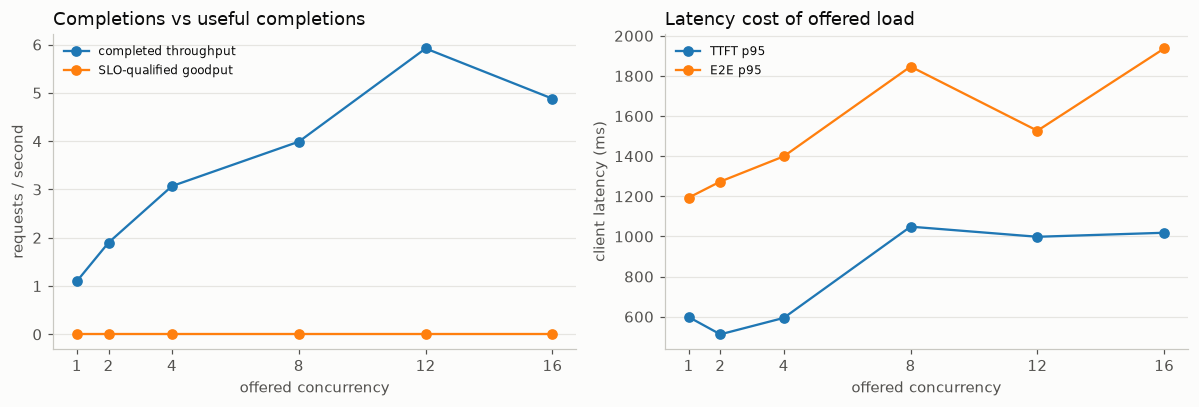

E0 capacity runner (synthetic, preliminary): first limiter = max_num_seqs_concurrency_limit | limiter by context = {'512': 'max_num_seqs_concurrency_limit', '2048': 'max_num_seqs_concurrency_limit', '8192': 'scheduler_long_context_batched_tokens_limit'}


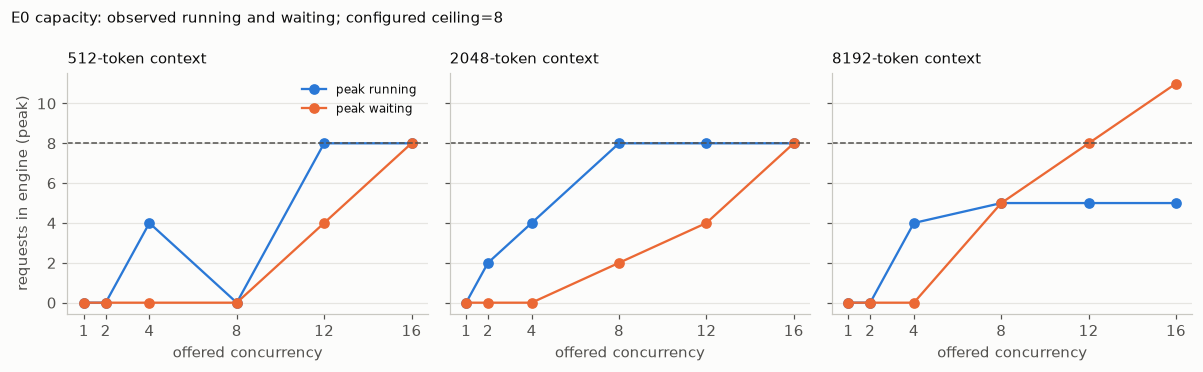

## Observed results and interpretation — E0

# E0 write-up: what runs out first when load goes up

Talk track for the presentation. Run: `d123-20261004-e0-2321` (2026-10-04), `make inference-capacity` plus a gateway concurrency sweep. Evidence: `metrics/inference/d123-20261004-e0-2321/`. Full analysis and caveats: `analysis/e0-analysis-d123-20261004-e0-2321.md`.
Numbers marked "measured" come from the run files; "computed" are my arithmetic; "inferred" are my reading, not measured.

## The one-sentence answer
On our two-worker A100 setup the first thing to run out is not GPU memory, it is the scheduler: each worker serves at most 8 requests at once (`--max-num-seqs 8`), so past that point requests queue and latency climbs while throughput stops growing. The KV cache stays far from full.

## 1. What E0 asks
Before testing caching, routing and admission, find the limit they all work around: as offered load rises, which resource saturates first (decode slots, KV cache, prefill compute, or the queue), and where does throughput stop improving?

## 2. What I ran
Two measurements, deliberately different:
1. **Synthetic capacity sweep** (`make inference-capacity`): unique prompts of 512, 2,048 and 8,192 tokens, concurrency 1 to 16, sent **directly to worker A** (no gateway). Answers "what does one worker do on its own".
2. **Application-shaped sweep** (`run_scenario.py --sweep-concurrency 1,2,4,8,12,16`): the taxi multi-turn trace (10 conversations, 39 turns) **through the gateway**, no policy override. Answers "what does the real request mix do".

Before the sweep I raised the gateway's per-tenant concurrency from the default 4 to 64. The trace sends no tenant, so it lands in a shared bucket that would have rejected everything above 4 concurrent with 429, and the sweep would have measured the quota, not the hardware. After the run: zero 429s, 39 of 39 turns succeeded at every level.

## 3. What the synthetic sweep showed (worker A, measured)
| Context | Conc. 1 | Conc. 8 | Conc. 16 | What limits it |
|---|---|---|---|---|
| 512 tokens | 26 tok/s | 50 tok/s | 54 tok/s | 8 decode slots; waiting grows to 8 at conc. 16 |
| 2,048 tokens | 26 tok/s | 48 tok/s | 49 tok/s | same; KV never above 23% |
| 8,192 tokens | 8 tok/s | 8 tok/s | **1.6 tok/s** | batched-token limit; TTFT 391 ms to 1,658 ms |

- Short contexts: throughput roughly doubles from conc. 1 to 8, then flattens. Running requests pin at 8 and the waiting count rises. That is the slot limit.
- Long contexts (8,192 tokens): throughput peaks at conc. 4 (12.4 tok/s), then falls. TTFT passes the 1,000 ms SLO; only 4 of 32 requests at conc. 16 qualify. KV peaks at 46% of the 71,200-token pool, so even here memory is not what stops it.
- Zero preemptions and zero errors anywhere.

## 4. What the application sweep showed (through the gateway, measured)
| Concurrency | req/s | tok/s | client TTFT p95 | E2E p95 |
|---|---|---|---|---|
| 1 | 1.10 | 140 | 599 ms | 1.19 s |
| 4 | 3.07 | 392 | 594 ms | 1.40 s |
| 8 | 3.99 | 511 | 1,049 ms | 1.85 s |
| 12 | **5.92** | **757** | 998 ms | 1.53 s |
| 16 | 4.88 | 622 | 1,018 ms | 1.94 s |

- Throughput climbs to about concurrency 12, then drops at 16. TTFT p95 steps up between 4 and 8, which is where queueing starts.
- Routing was fairly balanced: worker A 141 requests (60%), worker B 93 (40%).
- KV usage in the sweep window stayed at 3% or less. The first limiter for the real trace is also the slot/queue limit, not memory (range data: worker B running 8, waiting 2).

## 5. Why KV is not the limiter (and how I know)
Per token the KV cost is 112 KiB (computed, 2 x 28 layers x 8 KV heads x 128 x 2 bytes). Each worker's pool is 7.61 GiB = 71,200 tokens (vLLM log), so at 8,192 tokens/request memory alone would allow 8.69 conversations; at 512 tokens, 139. The 8-sequence cap bites first at every context length except 8,192, where the batched-token limit does. Details in the E1 write-up, section 1.

## 6. What NOT to say
- **Do not quote a goodput curve or "the knee".** Goodput is 0 at every level of the gateway sweep and the analysis tool reports `knee_offered_concurrency: 1`: that is an artifact. The replayer's SLO is TTFT 100 ms, but client TTFT through our SSH tunnel is already about 500-600 ms at concurrency 1. Quote raw throughput only; "about 12" is where raw throughput peaked, not a goodput knee.
- **Do not read the TTFT numbers as GPU latency.** Engine-side TTFT is 5-20 ms (E1); the 500-1,000 ms client numbers are mostly the tunnel plus queueing.
- **Do not attribute the 46% KV peak to the gateway sweep.** It came from the capacity run's 8,192-token cells (the Prometheus window covers both runs). In the sweep window KV peaked at 3% (worker B) and 1% (worker A). I made this mistake in my first reading.
- **Do not claim a precise knee or ranking between levels 8, 12 and 16.** One run of 39 turns per level (6-8 s each), Prometheus sampled every 15 s, and the sweep ascends over a repeated trace, so level 1 ran against a cold prefix cache and later levels against a warm one (prefix hit ratio 85-89%; inferred effect on the curve, not tested).

## 7. Takeaways for the later experiments
1. Policy and admission decisions in E3 and E4 matter once load exceeds about 8 concurrent per worker; below that, routing differences are hidden.
2. Because slots, not KV, fill first, a KV-aware admission signal alone would not protect latency; queue depth and running count are the earlier warning (relevant to E4 thresholds).
3. Tenant quota is part of the system under test: the default of 4 concurrent per shared bucket rejects the sweep outright. Restore the default before E4; E2 and E3 replay at concurrency 8 and still need it raised.

## 8. Open
- Re-running for a presentable goodput curve would need SLOs the tunnel can meet (or a client on the instance), a worker restart first, and longer levels. Not done; decision was to write up with the caveats and continue to E2.
- The pod-annotation and static-job scrapes disagree on exact running/waiting peaks (for example worker B running 8 vs 1). Unreconciled, so peaks are quoted as indicative.


In [3]:
if (p := need("E0_SWEEP")):
    run = load_run(p[0])
    curve = sweep_curve(run)
    show("Recorded latency SLOs (ms)", run.manifest.get("slos") or {"note": "SLO metadata unavailable"})
    if curve["rows"] and all(r[curve["knee_metric"]] == 0 for r in curve["rows"]):
        curve = {**curve, "knee_offered_concurrency": None,
                 "warnings": [*curve["warnings"], "All measured goodput values are zero: no useful goodput knee can be inferred."]}
    show("E0 offered load vs throughput vs goodput (knee)", curve)
    plot_sweep(curve)
if (p := need("E0_CAPACITY")):
    cap = json.loads((p[0] / "capacity_summary.json").read_text())
    print("E0 capacity runner (synthetic, preliminary): first limiter =", cap.get("first_limiter"), "| limiter by context =", cap.get("limiters_by_context"))
    plot_capacity(cap)
writeup("E0")


## E1 Cold vs declared-warm worker

**Question:** how much does the first request after a worker restart differ from steady service?

**Method:** restart the workers, wait for readiness, measure the first request and subsequent
requests, then repeat in the declared-warm state after an idle interval. This experiment
uses direct worker requests, so its path differs from the gateway replays.

**Read the chart:** compare each arm's first-request TTFT with its subsequent-request p50.
Full restart recovery, weight loading and CUDA graph capture require startup logs and readiness
timing; they are not measured by these bars. A small or absent gap does not prove the restart
failed: the engine may do expensive initialization before it becomes Ready.

**Expected behavior (hypothesis):** The first request may be slower than subsequent requests after readiness, but the gap can be small when startup performs initialization in advance. Startup recovery time is a separate measurement.

**Observed evidence:** charts and tables below use only supplied run artifacts; the session writeup records interpretation. Missing runs are skipped.

Compare the first observed request with subsequent-request p50. This is request latency after readiness, not full worker startup time. Empty summaries cannot prove warmup occurred.

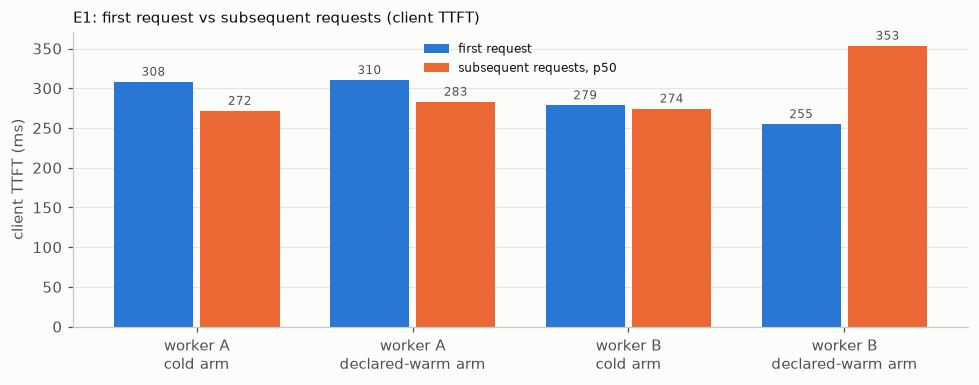

metric,value
cold_ttft_ms,308.08
warm_sample_count,5
warm_ttft_p50_ms,271.56
warm_ttft_p95_ms,276.83
unwarmed_request_ttft_ms,308.08
metric,value
cold_ttft_ms,278.62
warm_sample_count,5
warm_ttft_p50_ms,274.41
warm_ttft_p95_ms,281.47


## Observed results and interpretation — E1

# E1 write-up: what a restart does to the KV cache, and what the first request costs

Talk track for the presentation. Run: `d123-20261004-e1` (2026-10-04), `make inference-e1`. Evidence: `metrics/inference/d123-20261004-e1/`.
Numbers marked "log" come straight from the vLLM startup log; "computed" are my arithmetic; "inferred" are my reading, not measured.

## The one-sentence answer
After a worker restarts, the engine's first request is a few milliseconds slower; after waiting five idle minutes it is not slower at all. The big
numbers people see (250-350 ms) are our SSH tunnel, not the GPU, and the KV cache is nowhere near full for this workload.

## 1. The KV cache on our A100, in numbers
**Hardware.** One NVIDIA A100-SXM4-40GB (40,960 MiB). HAMi splits it into two 20 GiB slices, one per worker; inside each worker `nvidia-smi` reports 20,480 MiB total.

**What one token costs.** Qwen3-0.6B has 28 layers, 8 KV heads, head dim 128, bf16 (2 bytes). Per token, K and V together:
2 x 28 x 8 x 128 x 2 = **114,688 bytes (112 KiB)** (computed; the capacity runner prints the same number).

**What each worker reserves** (vLLM startup log, identical on both workers):
| Item | Value | Source |
|---|---|---|
| `--gpu-memory-utilization` | 0.45 of the 20 GiB slice = about 9.0 GiB budget | flag, computed |
| Model weights (bf16, 0.6B) | 1.12 GiB | log |
| **Available KV cache memory** | **7.61 GiB** | log |
| **GPU KV cache size** | **71,200 tokens** (= 4,450 blocks of 16 tokens) | log, block size 16 |
| Maximum concurrency at 8,192 tokens/request | 8.69x | log |
| CUDA graph capture | 1 s, 0.04 GiB | log |
| Rest of the budget (activations, overhead) | about 0.27 GiB | computed: 9.0 - 1.12 - 7.61 |

Check: 71,200 tokens x 114,688 B = 8.17 GB = 7.61 GiB, so the log and my per-token math agree. Resident per worker: about 9.4-9.5 GiB (`nvidia-smi` 9,571 MiB per pod; DCGM 9,726 MiB for one worker alone, 19,454 MiB for both).

**How many conversations fit** (71,200-token pool):
| Tokens per conversation | By KV memory alone | With `--max-num-seqs 8` |
|---|---|---|
| 512 | 139 | **8** |
| 2,048 | 34 | **8** |
| 8,192 | 8.69 | **8** (just under) |

Correction to my own earlier paper math: the capacity runner's printout (73 / 18 / 4 sequences) assumed a **4 GiB** KV budget, a default I never measured. The real budget is **7.61 GiB**, so the real ceilings are about 1.9x higher. Talking point: for our workload KV memory is not the first thing to run out; the scheduler's 8-sequence cap is (confirmed in E0: the limiter was `max_num_seqs` at 512 and 2,048 tokens, and the 8,192-token batch limit at the longest context).

**Preallocation.** vLLM takes the whole KV pool up front. GPU memory used therefore sits flat (19.4 GiB with both workers up) whether the cache holds nothing or a lot. A flat HBM line says nothing about KV pressure; `vllm:kv_cache_usage_perc` is the number that moves.

## 2. What E1 asks
When a worker restarts, three things reset: the weights reload, the KV pool is carved out again (empty), and the prefix cache (reusable KV blocks keyed by prompt content) starts empty. Question: does the first request after that pay a visible price, compared with the requests that follow, and compared with a first request after a long idle gap ("declared warm")?

## 3. What I ran
One command, `make inference-e1` (tunnel open in another terminal, a tmux window). It does, in order:
1. Load the E1 manifest (model revision, engine flags, vLLM 0.11.0, block size 16) and confirm gateway and both workers answer `/health`.
2. Restart worker B, then worker A. Each waits for readiness and a smoke probe. **Recovery: 94 s (B), 95 s (A).**
3. Wait until the tunnel's port-forwards re-attach (they die with the old pod; my first attempt skipped this and the cold run measured nothing).
4. Cold run: 1 "unwarmed" request plus 5 more to each worker, directly.
5. Wait 300 s with no traffic, then the same again (the warm run).
6. Pull the Prometheus time series for the whole window and a cluster snapshot.

Before it, I confirmed the live workers match the manifest (`make inference-verify-workers`: same args, vLLM 0.11.0, block size 16, revision = tokenizer revision, chunked prefill and prefix caching on) and added a startup probe to the worker manifests after a slow start was killed by the liveness probe in an earlier attempt.

## 4. What I saw
**Where the 95 s of restart goes** (worker log, one start): weights load 3.4-3.9 s, `torch.compile` about 32 s (58 s in an earlier, slower start), KV profiling and allocation, CUDA graph capture 1 s, "init engine" 43 s in total; the rest is scheduling the pod and starting Python. Nothing is served until all of it finishes.

**Inside the engine** (vLLM TTFT histogram, 6 requests per worker per run):
| Run | 5-10 ms | 10-20 ms | over 20 ms |
|---|---|---|---|
| Cold run (right after restart) | 5 | **1** | 0 |
| Warm run (after 300 s idle) | **6** | 0 | 0 |
The same on worker A and worker B. The slower request in the cold run is very probably the first one (inferred: it is the only one over 10 ms, and the warm run, whose first request also follows a long gap, has none). Engine TTFT is therefore **5-20 ms**, and the restart penalty is a few milliseconds at most (the buckets only bound it to roughly 0-15 ms).

**What the client measured** (through the SSH tunnel, 1 unwarmed then 5 warm):
| Run | Worker | unwarmed | warm p50 | warm p95 |
|---|---|---|---|---|
| cold | A | 308 ms | 272 | 277 |
| cold | B | 279 ms | 274 | 281 |
| warm | A | 310 ms | 283 | 355 |
| warm | B | 255 ms | 353 | 579 |
That is 250-350 ms with jitter up to 579 ms, against an engine TTFT under 20 ms, so about 95% of the client-side number is tunnel and network. Worker A's first request looks about 30 ms slower in both runs, but that is larger than the engine's whole TTFT, so it is not the engine (inferred: first connection through a fresh port-forward).

**KV pressure during E1:** none. Over the window `vllm:kv_cache_usage_perc` read 0, requests running and waiting were 0, preemptions 0. Each request is about 10 prompt and 10 generated tokens (roughly 20 tokens out of a 71,200-token pool), so this experiment shows the cost of a cold start, not of a full cache. (The 15 s scrape step can miss a 20-token blip.)

**GPU memory during the restarts:** DCGM used memory stepped between 19,454 MiB (both workers up) and 9,726 MiB (one worker down), a clean picture of one 9.7 GiB worker leaving and returning.

## 5. What I would say out loud
- "On a 40 GB A100 split in two, each worker gets a 7.6 GiB KV pool, about 71,000 tokens, which is 8.7 full 8k conversations; our scheduler admits 8, so the cache is not our bottleneck."
- "The pool is allocated at startup, so memory looks flat. The signal is the usage gauge, and in E1 it stayed at zero."
- "A restart costs about 95 seconds of no service. After that the first request is a few milliseconds slower inside the engine, and nothing after a five-minute idle."
- "If you measure from outside you will see 250-350 ms and think there is a cold-start problem. There is not; that is the tunnel."

## The real points in `vllm_ttft_p95.json`, and what 17.00 ms means
Only 3 points per series are real (22:39:36, 22:39:51, 22:40:06 local), all exactly **17.00 ms**, identical on both workers. That is the cold run. 17.00 is not a measured latency: it is Prometheus interpolating inside a histogram bucket. Of 6 requests, 5 were at or below 10 ms and 1 in the 10-20 ms bucket, so the p95 rank (0.95 x 6 = 5.7) falls inside that bucket: 10 + (5.7 - 5) / 1 x 10 ms = 17.0 ms. Read it as "one request in six was between 10 and 20 ms", the same finding as the bucket table above.
**The first export missed the warm run, so I re-pulled it** (first pull kept in `prometheus_range_first_pull/`). The original window ended at 22:44:29, the instant the warm run finished, but Prometheus scrapes every 15 s, so the warm run was not yet scraped. The re-pull (window to 22:57) now shows both runs, identical on worker A and B:
| Run | p95 TTFT points | Why that value |
|---|---|---|
| Cold (22:39:36-22:40:06) | 17.0 ms x 3 | 5 of 6 requests at or below 10 ms, 1 in 10-20 ms: rank 5.7 falls in the upper bucket, 10 + 0.7 x 10 = 17.0 |
| Warm (22:44:36-22:45:06) | 9.7 ms x 3 | all 6 requests in 5-10 ms: rank 5.7 of 6 inside that bucket, 5 + (5.7/6) x 5 = 9.75 |
Both are interpolated bucket positions, not measured latencies, but they agree with the bucket counts: the cold run has one request above 10 ms, the warm run has none. `run-e1.sh` now waits 30 s before ending the window, so a normal run exports both.

## Why many panels and numbers show NaN (say this before someone asks)
Prometheus quantile and mean panels divide one rate by another (a histogram quantile, or `sum/count`). With no requests in the window both rates are 0, so the result is 0/0 = **NaN**: "no data", not an error. In the E1 range export only `vllm_ttft_p95` is affected: 120 of its 132 points are NaN, and the 12 real points are exactly when the warm-up requests ran. The cluster is idle for most of the hour, so most of the time-series values are NaN by design. That is why this write-up quotes cumulative histogram bucket counts (which do not need traffic in a window) and the startup log. The gateway series (`orch_*`, `gateway_ttft_p95`) are empty, not NaN, because E1 sends requests straight to the workers.

## 6. Limits to be honest about
- One cold request per worker per run, one run; two workers agree, which helps but is not a statistical test.
- The 10-20 ms request being "the first one" is inferred; histograms cannot name a request. The penalty is bucket-bounded, not measured.
- The warmup prompt is tiny, so this says nothing about prefix reuse (that is E2) or KV pressure (E0/E4).
- The startup probe was in place but the slow-start failure did not recur, so it is untested under a slow start.
- KV figures (7.61 GiB, 71,200 tokens, 8.69x) are the engine's own startup log; I did not measure KV usage under load in this experiment.


In [4]:
if (p := need("E1_WARMUP_COLD", "E1_WARMUP_WARM")):
    cold, warm = (json.loads((d / "warmup_summary.json").read_text()) for d in p)
    groups, first, steady = [], [], []
    for worker in sorted(set(cold) | set(warm)):
        for name, run in (("cold arm", cold), ("declared-warm arm", warm)):
            if worker in run:
                groups.append(f"{worker_name(worker)}\n{name}")
                first.append(run[worker]["cold_ttft_ms"])
                steady.append(run[worker]["warm_ttft_p50_ms"])
    if plt:
        fig, ax = plt.subplots(figsize=(9, 3.6))
        bars(ax, groups, {"first request": first, "subsequent requests, p50": steady}, "client TTFT (ms)",
             "E1: first request vs subsequent requests (client TTFT)")
        plt.tight_layout()
        plt.show()
    show("E1 warmup observations", {"cold": cold, "declared_warm": warm})
writeup("E1")


## E2 Prefix reuse (cold vs reused)

**Question:** does an already populated prefix cache make the same trace faster?

**Method:** reset both workers, declare warmup, replay the trace once, then replay it again
without restarting. Keep scenario, policy, model, engine flags and SLOs fixed. If the replay
requests a policy override, the gateway experiment controls must be enabled for both arms.

**Read the charts:** focus on the first turn of each conversation, then compare later turns
and overall p50/p95. The cold arm warms its own cache as it runs, so this is first pass vs
reused cache, not disabled caching vs enabled caching. Cache-hit percentages are aggregate
window evidence and may include only one worker; they cannot identify a particular hit.

**Expected behavior (hypothesis):** The reused arm should reduce first-turn prefill latency when matching prefixes remain cached. Later turns may already reuse prefixes within the cold arm, so an improvement on every turn is not required.

**Observed evidence:** charts and tables below use only supplied run artifacts; the session writeup records interpretation. Missing runs are skipped.

Inspect turn 1 separately: the cold arm can reuse prefixes on its own later turns. Manifest parity gates causal comparisons; unmatched runs remain descriptive. Prometheus hit rates describe a window, never an individual request.

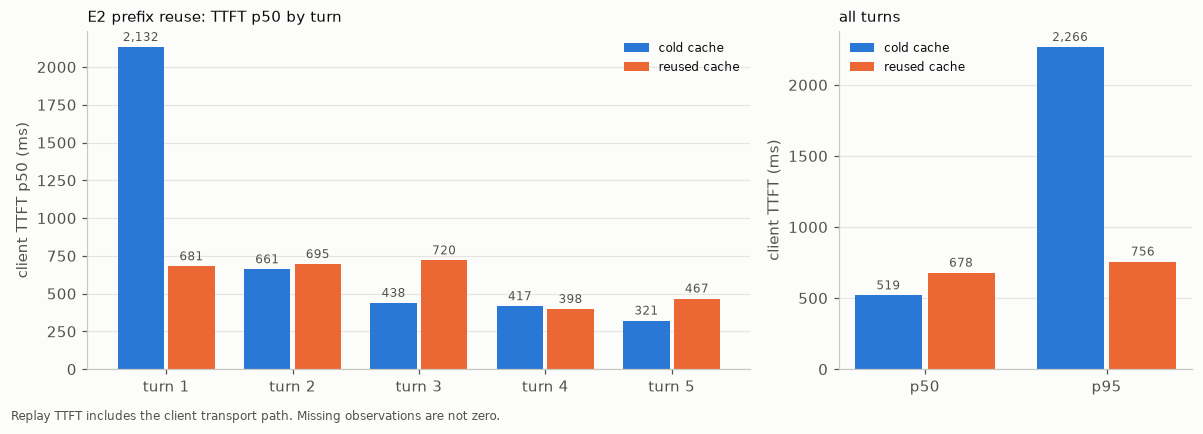

metric,value
scope,per-request (requests.jsonl) and WINDOW-level aggregate (Prometheus); NOT attributable to any single request
comparable,True
metric,value
match,True
proven,True
treatment_varied,False
comparable,True
metric,value
scope,per-request (requests.jsonl)
metric,value


## Observed results and interpretation — E2

# E2 write-up: does a warm prefix cache make the first turn faster?

Talk track for the presentation. Run: `d123-20261004-e2-2357` (2026-10-04/05), `make replay-e3-least-loaded` twice. Evidence: `metrics/inference/d123-20261004-e2-2357/` (the sibling `...-e2-2330` is the first, invalid attempt: see section 3). Numbers marked "measured" come from the run files; "inferred" is my reading, not tested.

## The one-sentence answer
With a cold prefix cache the first turn of each conversation took about 2.1 s; with the cache already warm the same turns took about 0.7 s (about 3x faster, measured). Later turns showed no benefit, because inside the cold run they already reuse their own conversation's prefix, so this comparison is "first pass vs fully warm", not "no cache vs cache".

## 1. What E2 asks
vLLM keeps a prefix cache: KV blocks keyed by prompt content, reused when a new request starts with the same tokens. Multi-turn chat resends the whole history each turn, so most of each prompt is a repeat. Question: how much faster is a request when the cache already holds its prefix than when it does not?

## 2. What I ran
Both arms use the SAME scenario (`e3_routing_mixed`: 10 conversations, 39 turns, concurrency 8), the SAME policy override (`least_loaded`, so both workers see traffic and both build prefixes), the same SLOs, revisions and engine flags. Only the cache state differs:
1. Restart both workers (empty prefix caches), then a declared warm-up that exercises the engine without loading the trace's prefixes.
2. **Cold arm** (`e2-cold`): replay the trace.
3. **Reused arm** (`e2-reused`): replay the identical trace immediately after, no restart.
4. Pull the Prometheus range after waiting for the tail to be scraped.

Gateway state: experiment controls on (needed for the policy override) and tenant quota raised to 64 (the replay runs at concurrency 8 and the shared bucket allows 4 by default).

## 3. Validity
- The comparator `e2_prefix_reuse` reports `comparable: true` and `proven: true`; the two manifests differ only in label and timestamps. Policy override verified on every turn (`control_unverified_turns` = 0).
- 39 of 39 turns succeeded in both arms; no 429s.
- First attempt (`...-e2-2330`) was invalid: the gateway had controls off (policy override not echoed) and the default quota (429s at concurrency 8). Its few successful requests had also warmed the caches, so I restarted the workers and started a new run folder. Kept for the record.

## 4. What I saw (client-side TTFT through the tunnel, measured)
| Turn | Requests | Cold p50 | Reused p50 | Cold p95 | Reused p95 |
|---|---|---|---|---|---|
| 1 | 10 | **2,132 ms** | **681 ms** | 2,267 | 721 |
| 2 | 10 | 661 | 695 | 746 | 707 |
| 3 | 10 | 438 | 720 | 555 | 791 |
| 4 | 6 | 417 | 398 | 516 | 450 |
| 5 | 3 | 321 | 467 | 323 | 490 |
| All turns | 39 | 519 | 678 | **2,266** | **756** |

- Turn 1 is the effect: the first prompt of each conversation pays full prefill on a cold cache. The overall p95 falls from 2,266 to 756 ms because of it.
- From turn 2 on there is no reliable benefit. The overall p50 is actually higher in the reused arm (678 vs 519 ms); that comes from the turn 2-3 spread, not a regression I can explain by caching. Treat turns 2-5 as a tie within noise.
- Placement: cold 22 requests to worker A and 17 to worker B; reused 18 and 21. `least_loaded` does not use prefix affinity, so a conversation can land on a different worker in the second arm; that is why E2 uses `least_loaded` (both workers build the prefix) rather than a prefix-aware policy.

## 5. What the Prometheus window says (and does not)
Window prefix-cache hit rate: **81.8% cold, 79.3% reused** (-2.5 points; worker-A scrape, aggregate over the whole run). That is NOT the proof: the cold run already reaches about 82% because turns 2-5 hit their own conversation's prefix. The per-request turn-1 TTFT is the evidence; the window rate cannot be attributed to any single request.

## 6. What NOT to say
- **Not "caching makes everything 3x faster".** Only the first turn of each conversation moved; later turns did not.
- **Not "no cache vs cache".** The cold arm is already partly cached after its own first turns.
- **The turn-1 gap is probably the cold prefix cache, but I did not isolate it.** First-use cost on freshly restarted workers (inferred) could add to it.
- **Absolute TTFT includes the tunnel.** Both arms sit around 400-700 ms for later turns, which is mostly tunnel plus queueing, as in E0; engine-side TTFT is 5-20 ms (E1).
- **Ignore goodput and the tool's knee.** Goodput is 0 (replayer SLO 100 ms vs about 500 ms client TTFT through the tunnel).
- **One run per arm, 10 first turns each.** No confidence interval.

## 7. Side evidence: a slow worker restart
Worker A took **135 s** to become Ready this time (E1: 94-95 s) and still passed its smoke probe. That is the slow-start case the `startupProbe` was added for (earlier a liveness probe killed a slow start at about 120 s). I have not checked the pod events to confirm the probe was what let it survive, so this is "consistent with", not proven.

## 8. Takeaways
1. Prefix reuse pays off on the first turn of a conversation, the one place a router can still save a full prefill. That motivates E3: a prefix-aware policy should send a conversation back to the worker that holds its prefix.
2. For a fair "cache vs no cache" number, restart before each run and use concurrency 1 with a single conversation (noted in the playbook); not done here.
3. Keep the quota at 64 for E3 (it replays at concurrency 8); restore the default only before E4.


In [5]:
if (p := need("E2_COLD", "E2_REUSED")):
    cold, reused = load_run(p[0]), load_run(p[1])
    compare_by_turn("E2 prefix reuse", "cold cache", cold, "reused cache", reused)
    show("E2 prefix reuse (cold vs reused)", e2_prefix_reuse(cold, reused))
writeup("E2")


## E3 Routing: least_loaded vs prefix_then_load

**Question:** does prefix affinity save enough prefill work to outweigh queueing on a preferred worker?

**Method:** replay the same multi-turn taxi trace with `least_loaded` (spread by current load)
and `prefix_then_load` (prefer a reusable prefix when overlap and headroom allow, otherwise
fall back to load). Reset both workers before each arm and verify the requested policy was
applied. Only the routing policy should differ.

**Read the charts:** inspect first-turn and later-turn TTFT separately, overall tail latency
and worker request counts. A policy can improve later turns while worsening the first burst.
For the headline trace, the roughly 270-token system prefix becomes a smaller share as history
grows: the 0.8 overlap gate is expected to produce `prefix_overlap_low` from turn 2 onward.
This policy measures system-prefix affinity, not history-aware conversation stickiness.
The optional roughly 6k-token synthetic-prefix variant is a separate treatment.

**Expected behavior (hypothesis):** Prefix affinity may improve reuse but concentrate a cold burst on one worker. With the headline trace, the overlap gate should fall back to load from turn 2; a uniform latency improvement is not guaranteed.

**Observed evidence:** charts and tables below use only supplied run artifacts; the session writeup records interpretation. Missing runs are skipped.

Compare first-turn and later-turn latency, tail latency and worker distribution together. Better reuse can trade off against queueing on one worker. Check manifest parity and policy verification before declaring a winner; a single pair does not establish a repeatable advantage.

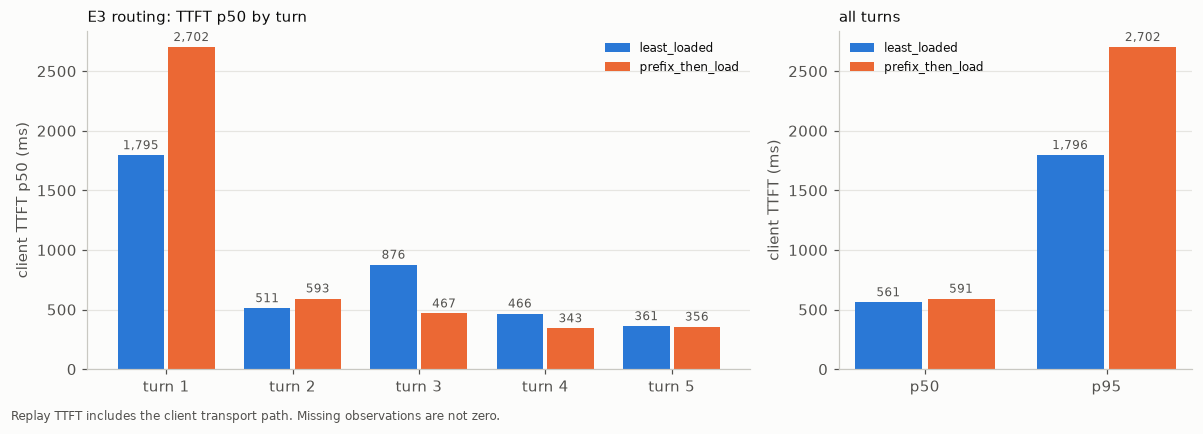

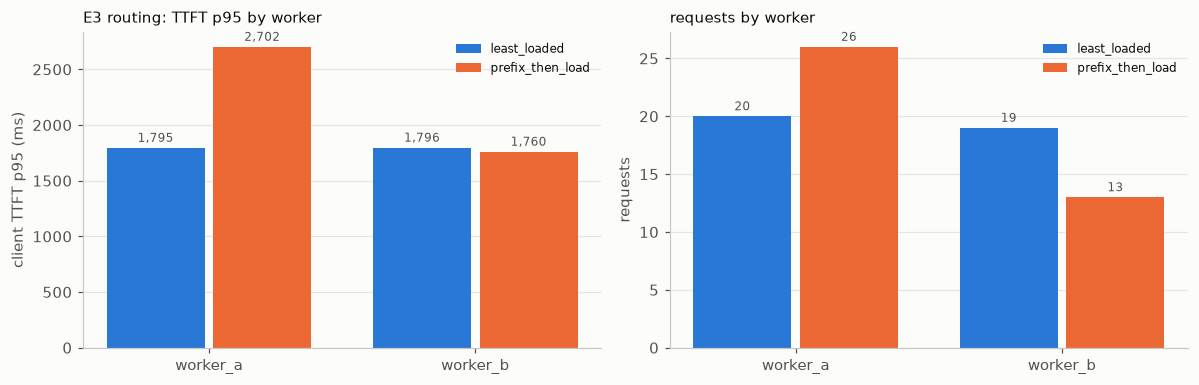

metric,value
scope,per-request (requests.jsonl); goodput is run-level
comparable,True
metric,value
match,True
proven,True
treatment_varied,True
comparable,True
metric,value
label,e3-least_loaded
requests,39


## Observed results and interpretation — E3

# E3 write-up: does prefix-aware routing beat least-loaded routing?

Talk track for the presentation. Run: `d123-20261005-e3-0040` (2026-10-05), `make replay-e3-least-loaded` then `make replay-e3-prefix-then-load`. Evidence: `metrics/inference/d123-20261005-e3-0040/`. Detailed numbers: `analysis/e3-analysis-d123-20261005-e3-0040.md`. Numbers marked "measured" come from the run files; "inferred" is my reading, not tested.

## The one-sentence answer
On this small trace, prefix-aware routing (`prefix_then_load`) was better on later turns (turn 3 TTFT p50 467 vs 876 ms, e2e p50 1.19 vs 1.51 s, throughput +10%, measured) but worse on the first turn of each conversation (p50 2.70 vs 1.80 s, measured), and the first-turn burst dominates the p95 (2,702 vs 1,796 ms). So: a trade-off, not a clear win, from one run per arm.

## 1. What E3 asks
Two workers each keep their own prefix cache. A router that sends a conversation back to the worker already holding its prefix should avoid repeated prefill. A router that only looks at load (`least_loaded`) spreads conversations and may miss the cache. Question: does `prefix_then_load` (prefer the worker with the prefix, fall back to load) give lower latency than `least_loaded`?

## 2. What I ran
Same scenario both arms (`e3_routing_mixed`: 10 conversations, 39 turns, concurrency 8), same SLOs, revisions and engine flags. Only the policy override differs (sent per request; the gateway echoes it, so the replayer would have aborted if controls were off).
1. Restart both workers, declared warm-up, **arm 1** `least_loaded`.
2. Restart both workers again, warm-up again, **arm 2** `prefix_then_load`. Restarting before each arm gives both the same empty-cache starting state.
3. Pull the Prometheus range after the tail is scraped.

Gateway state: experiment controls on, tenant quota 64.

## 3. Validity
- `e3_compare`: `comparable: true`, `proven: true`; only `policy_override` differs; no treatment problems.
- 39 of 39 turns succeeded in both arms; no 429s; the requested policy was applied on every request.
- **The warm-up wrote empty summaries (`{}`)** for both arms, so I cannot show that the declared warm-up did what it should. Symmetric across arms, so the comparison holds, but I do not claim a "warmed" state. Cause not investigated.

## 4. What I saw (client-side TTFT through the tunnel, measured)
| | least_loaded | prefix_then_load |
|---|---|---|
| TTFT p50 / p95 | 561 / 1,796 ms | 591 / 2,702 ms |
| e2e p50 / p95 | 1,506 / 2,612 ms | 1,188 / 3,059 ms |
| Throughput | 3.49 req/s (444 tok/s) | 3.85 req/s (492 tok/s) |
| Placement A / B | 20 / 19 | 26 / 13 |

| Turn | Requests | TTFT p50 least_loaded | TTFT p50 prefix_then_load |
|---|---|---|---|
| 1 | 10 | 1,795 ms | 2,702 ms |
| 2 | 10 | 511 | 593 |
| 3 | 10 | 876 | 467 |
| 4 | 6 | 466 | 343 |
| 5 | 3 | 361 | 356 |

- **Turn 1:** `prefix_then_load` put 9 of 10 first turns on worker A (reason `prefix_affinity`). A burst of cold prefills all queued on one worker. `least_loaded` spread the same burst over both workers. The cost of concentrating is about 0.9 s on those requests (measured); the queueing explanation is inferred.
- **Later turns:** the prefix-aware arm reused more: `local_reuse` on 25 of 39 requests vs 2 of 39 (measured). Turns 3-4 are faster.
- **From turn 2 the router stopped using affinity:** all 29 follow-up requests were placed with reason `prefix_overlap_low`, i.e. by load. 6 of 10 conversations still touched both workers. So the policy as run is not conversation-sticky. I have not checked why overlap was judged low; that is the first thing to look at before judging the policy.

## 5. What the Prometheus window says (and does not)
Window prefix-cache hit rate on worker A: 72.4% (least_loaded) vs 83.3% (prefix_then_load). Not clean evidence: worker A received 20 vs 26 requests, and it is one worker's aggregate. The per-request TTFT and `local_reuse` counts are the evidence. The Prometheus range itself adds little: 15 s scrapes against 10-11 s runs, no waiting requests, KV usage at most 2%.

## 6. What NOT to say
- **Not "prefix routing is faster".** It lost on p95 and on turn 1; it won on turns 3-4 and throughput.
- **Not a statistically established result.** One run per arm, 10 first turns each, no confidence interval; arm order was fixed (least_loaded first), each arm freshly restarted.
- **Not a ceiling for prefix-aware routing.** The router used affinity on turn 1 only, and this prefix is short, so a cache miss is cheap. The optional large-prefix scenario was not run.
- **Absolute TTFT includes the tunnel** (about 300+ ms floor); engine-side TTFT is 5-20 ms (E1).
- **Ignore goodput.** It is 0 in both arms (100 ms SLO vs about 500 ms client TTFT).

## 7. Takeaways
1. Where routing places the cold burst matters: sending every first turn to the worker that "owns" the prefix serializes the cold prefill. Prefix affinity needs a load guard on bursts.
2. Prefix-aware placement does raise reuse (`local_reuse` 2 -> 25) and helps mid-conversation turns, but only if follow-up turns keep their affinity.
3. Next evidence to get if time allows: why `prefix_overlap_low` on turns 2+, the large-prefix variant, and a repeat of each arm to see run-to-run spread.


In [6]:
if (p := need("E3_LEAST_LOADED", "E3_PREFIX_THEN_LOAD")):
    ll, ptl = load_run(p[0]), load_run(p[1])
    compare_by_turn("E3 routing", "least_loaded", ll, "prefix_then_load", ptl)
    compare_breakdown("E3 routing", "worker", "least_loaded", ll, "prefix_then_load", ptl)
    show("E3 least_loaded (a) vs prefix_then_load (b)", e3_compare(ll, ptl))
writeup("E3")


## E4 Admission on vs off

**Question:** can early admission shedding protect interactive goodput during overload?

**Method:** use the same mixed interactive/noisy/batch trace with capacity/deadline admission
off and on. Enable experiment controls and the tenant allowlist, and ensure the offered
load actually overloads the workers. Admission off still enforces tenant quotas.

**Read the evidence:** compare class-specific latency and useful completions, shed reasons,
queue timeouts and fairness. Lower latency among survivors is insufficient if interactive
goodput falls or batch work starves. Proving shed requests never reached the engine needs
correlated gateway and worker evidence; these latency charts alone do not establish it.

**Expected behavior (hypothesis):** Under genuine overload, early shedding should preserve interactive goodput and limit tail latency while avoiding unacceptable batch starvation. Lower raw throughput can be an intentional trade-off.

**Observed evidence:** charts and tables below use only supplied run artifacts; the session writeup records interpretation. Missing runs are skipped.



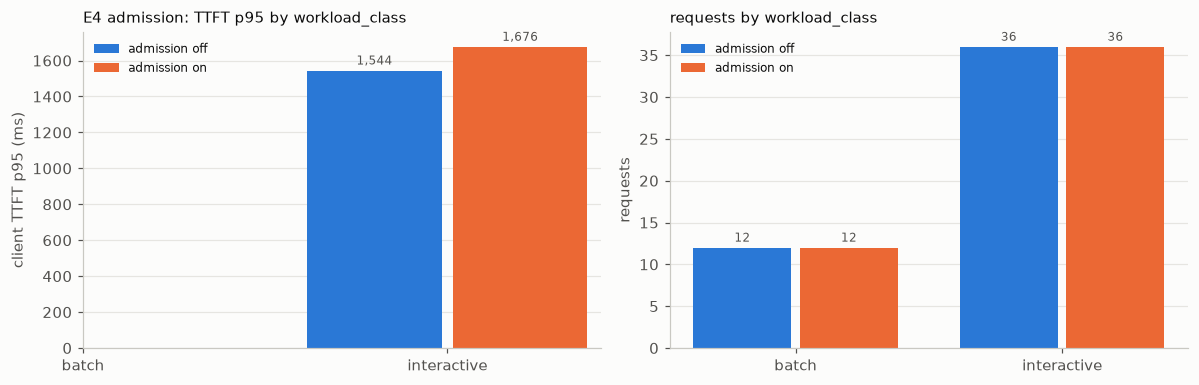

metric,value
scope,per-request (requests.jsonl); goodput is run-level
comparable,True
metric,value
match,True
proven,True
treatment_varied,True
comparable,True
metric,value
label,e4-admission_off
requests,48


## Observed results and interpretation — E4

# E4 write-up: does admission control protect interactive traffic under overload?

Talk track for the presentation. Run: `d123-20261010-e4-0003` (2026-10-10), `make replay-e4-admission-off` then `make replay-e4-admission-on`. Evidence: `metrics/inference/d123-20261010-e4-0003/`. Detailed numbers: `analysis/e4-analysis-d123-20261010-e4-0003.txt`, `analysis/e4-compare-d123-20261010-e4-0003.json`, `analysis/e4-requests-by-tenant-d123-20261010-e4-0003.txt`. Numbers marked "measured" come from the run files; "inferred" is my reading, not tested.

## The one-sentence answer
On this trace admission ON did **not** protect interactive traffic by serving more of it: it served fewer requests in total (20 vs 32 of 48) and shed 4 of the 12 `tenant_interactive` turns at the door (`decode_slots`), while the requests it did admit saw shorter tails (interactive TTFT p95 638 vs 1,048 ms, gateway queue wait p95 0 vs 540 ms, measured). The OFF arm never really overloaded the engine, so the shedding bought tail latency that the OFF arm did not need. A neutral-to-negative result from one run per arm.

## 1. What E4 asks
Under overload, shedding at the door (guard, then admission) should keep interactive latency and goodput from collapsing, and the tenant quota should stop one noisy tenant owning the GPU. Question: with admission ON, does interactive traffic do better than with admission OFF, on the same overload trace?

## 2. What I ran
Same scenario both arms (`e4_admission_overload`: 22 conversations, 48 turns, concurrency 22; `tenant_interactive` 6 conversations, `tenant_noisy` 12, `tenant_batch` 4; interactive deadlines 1,500-2,000 ms). Only the admission mode differs (`x-admission-mode: off` skips capacity and deadline shedding; the tenant quota still runs).
1. Cluster refreshed to the manifests (`make inference-refresh`), controls on, both workers warm and ramp 0.
2. **Arm 1** admission OFF, **arm 2** admission ON (about 20 minutes later; whether the workers were restarted between arms was not recorded, so cache state is not proven equal).
3. Prometheus range, evidence pull and gateway counter snapshots (start and end).

Gateway state: `TENANT_MAX_CONCURRENCY=10` (per tenant; the code default of 4 would cap three tenants at 12 in flight, below the 16 decode slots, so slot shedding could never fire), `MAX_DECODE_SLOTS=8` per worker (16 total), batch limited to 6 slots per worker (`BATCH_SLOT_RESERVE` 0.25), `PREFILL_TOKENS_PER_S=4000` and `QUEUE_WAIT_PER_WAITING_S=0.25` still placeholders, overflow off.

## 3. Validity
- `e4_compare`: `comparable: true`, `proven: true`, only the admission mode differs, no treatment problems.
- The replayer exits 1 on both arms because some turns were shed or failed; that is expected, the evidence was written.
- Gateway counters match the per-request rows (429 `tenant_concurrency` 8 total = 4 per arm; 503 `decode_slots` 24, all in the ON arm).
- Client latency goes through the SSH tunnel, so **goodput is 0 in both arms** (100 ms TTFT SLO vs about 600 ms client TTFT). I do not use goodput or the SLO.

## 4. What I saw (per-request, measured)
| | OFF | ON |
|---|---|---|
| Completed turns | 32 of 48 | 20 of 48 |
| `tenant_interactive` completed | 12 of 12 | 8 of 12 |
| `tenant_noisy` completed | 20 of 24 | 12 of 24 |
| `tenant_batch` completed | 0 of 12 | 0 of 12 |
| Failures | 12 x 503 `batch_slot_cap`, 4 x 429 `tenant_concurrency` | 24 x 503 `decode_slots` (12 batch, 8 noisy, 4 interactive), 4 x 429 `tenant_concurrency` |
| `tenant_interactive` TTFT p50 / p95 | 594 / 1,048 ms | 622 / 638 ms |
| `tenant_interactive` queue wait p95 | 540 ms | 0 ms |
| Gateway queue wait p95 (all) | 1,215 ms | 1,253 ms |
| `timeout_queue` | 0 | 0 |
| Jain fairness (completed) / served-fraction version | 0.627 / 0.661 | 0.641 / 0.653 |
| Placement worker A / B | 15 / 17 | 10 / 10 |

- **ON shed the batch tenant first, as designed** (all 12 batch turns), but also 8 interactive-class turns from `tenant_noisy` and 4 from `tenant_interactive`. Admission is class-aware, not tenant-aware, so noisy's interactive traffic competes with the good tenant for the same slots.
- **OFF still protected itself** through two layers that survive the off switch: the tenant cap (4 x 429 on noisy) and the batch slot cap at placement (12 x 503). So the OFF arm is not a "no protection" baseline.
- **Batch is starved in both arms** (`batch_starved: true`), by placement in OFF and by admission in ON.

## 5. Why (mostly inferred)
- **The OFF arm did not overload the engine.** Window means over both arms, from Prometheus: vLLM queue time about 23 microseconds, `vllm:num_requests_waiting` max 0 on both workers, effective prefill about 20,000 tokens/s (A 19,301, B 21,174; includes prefix-cache hits at about 90%, so an upper bound on the uncached rate). The gateway held every queue (`WORKER_MAX_INFLIGHT` equals `--max-num-seqs`), with waits of at most about 1.2 s, inside the 1.5 s deadline. (measured)
- **So the shed requests would likely have succeeded in time** (inferred). The ON arm turned queueing delay into immediate 503s.
- **Why ON shed that early is not checked.** My guess: slot occupancy is counted conservatively (running plus recent dispatches inside a grace window), so a 22-wide burst looks full. To confirm, read `occupied` against `running` in the gateway log for one `decode_slots` shed.
- **`deadline_unachievable` (504) never fired**, as the code predicts: its estimate uses vLLM `waiting` (always 0 here) plus a prefill term of about 0.03-0.13 s against a 1.5 s deadline. `QUEUE_WAIT_PER_WAITING_S` has no effect in this setup.

## 6. What NOT to say
- **Not "admission control protects interactive traffic" or "admission failed".** It shows the shed-versus-queue trade-off: tighter tails for admitted requests, fewer requests served.
- **Not a statistically established result.** One run per arm, 8-12 interactive requests, no confidence interval; arm order fixed (OFF first); no restart between arms recorded.
- **Not evidence about real overload.** The trace kept in-flight work about equal to the 16 slots; the engine never queued. A heavier trace (arrival-rate mode, longer decodes) is needed to show OFF degrading.
- **Not a tenant-protection result.** The only tenant limit is the concurrency cap, and at 10 `tenant_noisy` can still hold 10 of 16 slots.
- **Ignore goodput** (0 in both arms; tunnel).

## 7. Takeaways
1. Defense in depth held even with admission OFF: the tenant cap and the batch slot cap still acted. Which stage kills what is visible by reason in the counters (`orch_shed_total{reason}`, placement error `batch_slot_cap`).
2. Shedding at the door is only better than queueing when queue wait would exceed the deadline. Here it would not have, so the door was too strict for this trace.
3. The gateway queue, not vLLM's, is where this system queues; vLLM's `waiting` stays 0. Admission signals based on vLLM `waiting` therefore cannot see the queue (an explanation for the 504 path being unreachable).
4. If time allows: one shed request's gateway log (`occupied` vs `running`), a heavier trace where OFF actually degrades, and a repeat of each arm for run-to-run spread.


In [7]:
if (p := need("E4_ADMISSION_OFF", "E4_ADMISSION_ON")):
    off, on = load_run(p[0]), load_run(p[1])
    compare_breakdown("E4 admission", "workload_class", "admission off", off, "admission on", on)
    show("E4 admission off (a) vs on (b)", e4_compare(off, on))
writeup("E4")


## E5 Recompute control

**Question:** how does reusing a prefix locally compare with recomputing it on another worker?

**Method:** use separate labelled controls across prefix sizes: A-to-A local reuse, A-to-B
recompute without transfer, and a B destination warmed independently. Check exact token
counts in manifests rather than relying on size labels. Reset caches between independent cases.

**Read the evidence:** the current cell shows one supplied run's turn/worker latency, not a
multi-size crossover analysis. A separately warmed B cache is a destination hit, not transferred
KV. Real cross-worker KV transfer and its crossover remain dependent on #133 and explicit
transfer/reuse proof; a worker change or latency drop cannot prove a hop.

**Expected behavior (hypothesis):** A cached destination may avoid repeated prefill relative to recompute. These controls establish locality costs; a transfer crossover cannot be observed until real KV transfer is implemented and measured.

**Observed evidence:** charts and tables below use only supplied run artifacts; the session writeup records interpretation. Missing runs are skipped.



In [8]:
if (p := need("E5_RUN")):
    run = load_run(p[0])
    if plt:
        turns, p50 = turn_stat(run, "p50")
        _, p95 = turn_stat(run, "p95")
        fig, ax = plt.subplots(figsize=(8, 3.4))
        bars(ax, turns, {"p50": p50, "p95": p95}, "client TTFT (ms)", "E5 TTFT by turn")
        plt.tight_layout()
        plt.show()
    show("E5 TTFT by turn", ttft_by_turn(run))
    show("E5 latency by worker", breakdown(run, "worker"))


run directory not provided: set RUNS['E5_RUN']; skipping this experiment


## Memory proof

**Question:** do memory usage and scheduler activity support the claimed bottleneck?

**Method:** align HBM allocation, KV usage and running/waiting series over a supplied
Prometheus range. This supports E0 or E4; it is not a separate numbered experiment.

**Read the chart:** flat HBM can reflect preallocated vLLM memory while KV occupancy changes.
All available series are shown separately; duplicate scrape sources can disagree and should
not be summed. Samples can miss short bursts. The supplied range may include several workloads;
restrict the time window before attributing a peak to one experiment.

**Expected behavior (hypothesis):** Preallocated HBM can stay flat while KV occupancy and queueing vary. Resource pressure should align in time with workload activity; short bursts may be missed by coarse samples.

**Observed evidence:** charts and tables below use only supplied run artifacts; the session writeup records interpretation. Missing runs are skipped.



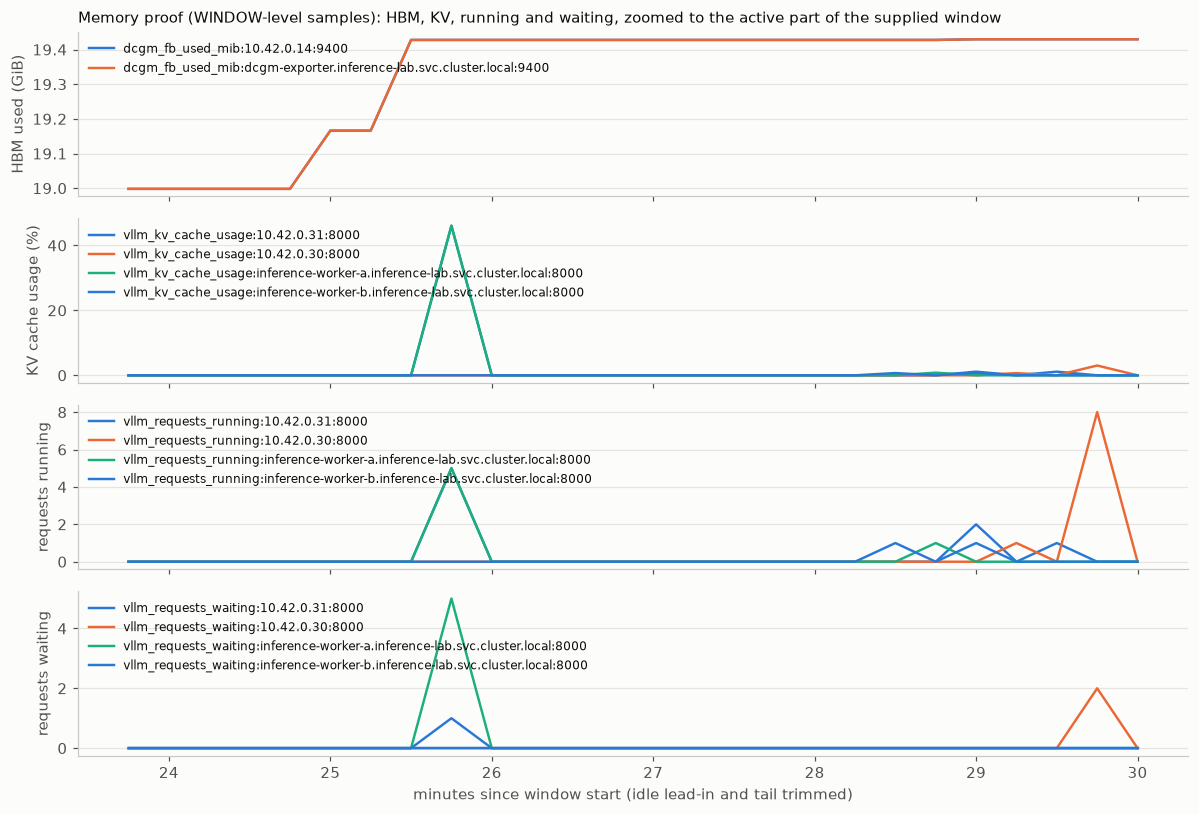

flags: none | warnings: none


In [9]:
if (p := need("MEMORY_RANGE")):
    res = memory_proof(p[0])
    plot_memory(res)
    print("flags:", res["flags"] or "none", "| warnings:", res["warnings"] or "none")


## Gateway queue vs engine waiting proof

**Question:** where does the engine scheduler sit vs the gateway admit/place/queue stages?

**Method:** align gateway replica queue depth (`orch_replica_queue_depth` by worker and class) and
queue wait (`orch_queue_wait_p95`) against vLLM waiting (`vllm:num_requests_waiting`), running
(`vllm:num_requests_running`) and preemptions (`vllm:num_preemptions_total`) over the run window.

**Read the chart:** under overload, gateway queues absorb excess work while vLLM waiting remains
bounded or zero, verifying the gateway preserves engine responsiveness and prevents uncoordinated
head-of-line blocking. Non-zero preemptions confirm engine-level KV evictions.

**Expected behavior (hypothesis):** Gateway replica queues absorb offered load over the concurrency limit while vLLM waiting remains near zero, proving the gateway queue protects the engine scheduler rather than duplicating it.

**Observed evidence:** charts and tables below use only supplied run artifacts; the session writeup records interpretation. Missing runs are skipped.



metric,value
peak,0.00
mean,0.00
metric,value
peak,0.00
mean,0.00
metric,value
peak,0.00
mean,0.00
metric,value
peak,0.00


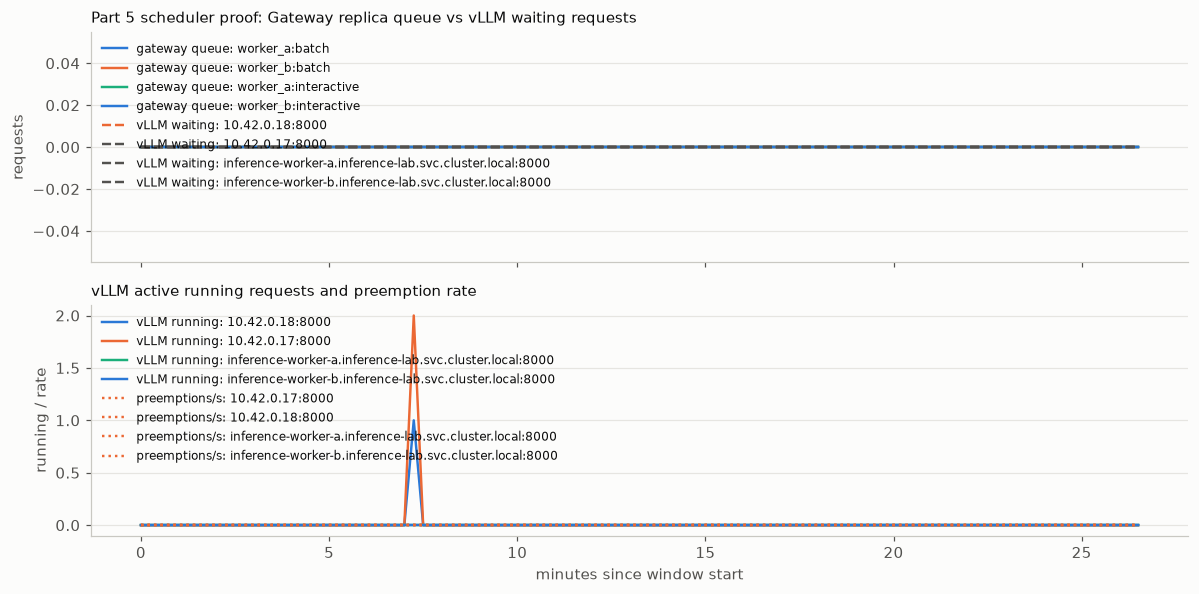

In [10]:
if (p := need("QUEUE_RANGE")):
    res = queue_proof(p[0])
    show("Gateway queue vs vLLM waiting summary", res["summary"])
    plot_queue(res)
    if res["warnings"]:
        print("warnings:", res["warnings"])
